# H2 Reproducibility Benchmark

This notebook measures three things on one shared H2 problem:

- per-seed energy spread across methods
- noisy vs noiseless variance where supported
- cache-hit vs forced-rerun timing

It uses only the packaged public APIs: `run_vqe`, `run_qite`, and `run_qpe`.

In [6]:
from __future__ import annotations

import json
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from common.hamiltonian import get_exact_spectrum
from common.paths import results_dir
from qite import run_qite
from qpe import run_qpe
from vqe import run_vqe

MOLECULE = "H2"
SEEDS = [0, 1, 2, 3]
EXACT_GROUND = get_exact_spectrum(MOLECULE, k=1)[0]


def timed_call(fn, /, **kwargs):
    t0 = time.perf_counter()
    result = fn(**kwargs)
    return result, time.perf_counter() - t0


def summary_stats(values):
    arr = np.asarray(values, dtype=float)
    return {
        "mean": float(arr.mean()),
        "std": float(arr.std(ddof=0)),
        "min": float(arr.min()),
        "max": float(arr.max()),
    }


def recent_artifacts(kind, limit=3):
    root = results_dir(kind)
    files = sorted(root.glob("*.json"), key=lambda p: p.stat().st_mtime, reverse=True)
    notes = []
    for path in files[:limit]:
        payload = json.loads(path.read_text())
        notes.append(
            {
                "file": path.name,
                "keys": sorted(payload.keys())[:8],
                "size_bytes": path.stat().st_size,
            }
        )
    return notes


EXACT_GROUND

-1.1372701748841751

In [ ]:
records = []

for seed in SEEDS:
    vqe_base = dict(
        molecule=MOLECULE,
        ansatz_name="UCCSD",
        optimizer_name="Adam",
        steps=75,
        stepsize=0.2,
        plot=False,
        seed=seed,
    )
    for noisy, dep in [(False, 0.0), (True, 0.05)]:
        res, runtime_s = timed_call(
            run_vqe,
            **vqe_base,
            noisy=noisy,
            depolarizing_prob=dep,
            force=True,
        )
        records.append(
            {
                "method": "VQE",
                "variant": "noisy" if noisy else "noiseless",
                "seed": seed,
                "energy": float(res["energy"]),
                "abs_error": abs(float(res["energy"]) - EXACT_GROUND),
                "runtime_s": runtime_s,
                "num_qubits": int(res["num_qubits"]),
            }
        )

    qite_res, runtime_s = timed_call(
        run_qite,
        molecule=MOLECULE,
        ansatz_name="UCCSD",
        steps=75,
        dtau=0.2,
        plot=False,
        show=False,
        seed=seed,
        force=True,
    )
    records.append(
        {
            "method": "VarQITE",
            "variant": "noiseless",
            "seed": seed,
            "energy": float(qite_res["energy"]),
            "abs_error": abs(float(qite_res["energy"]) - EXACT_GROUND),
            "runtime_s": runtime_s,
            "num_qubits": int(qite_res["num_qubits"]),
        }
    )

    qpe_base = dict(
        molecule=MOLECULE,
        n_ancilla=4,
        t=1.0,
        trotter_steps=2,
        shots=1000,
        plot=False,
        seed=seed,
    )
    for noisy, dep in [(False, 0.0), (True, 0.05)]:
        res, runtime_s = timed_call(
            run_qpe,
            **qpe_base,
            noisy=noisy,
            depolarizing_prob=dep,
            force=True,
        )
        records.append(
            {
                "method": "QPE",
                "variant": "noisy" if noisy else "noiseless",
                "seed": seed,
                "energy": float(res["energy"]),
                "abs_error": abs(float(res["energy"]) - EXACT_GROUND),
                "runtime_s": runtime_s,
                "num_qubits": int(res["num_qubits"]),
            }
        )

records[:3]

Step 01/75: E = -1.116684 Ha
Step 02/75: E = -1.136994 Ha
Step 03/75: E = -1.131007 Ha
Step 04/75: E = -1.122700 Ha
Step 05/75: E = -1.130115 Ha
Step 06/75: E = -1.133031 Ha
Step 07/75: E = -1.134496 Ha
Step 08/75: E = -1.134652 Ha


Step 09/75: E = -1.132102 Ha
Step 10/75: E = -1.130839 Ha
Step 11/75: E = -1.133769 Ha
Step 12/75: E = -1.136856 Ha
Step 13/75: E = -1.136817 Ha
Step 14/75: E = -1.134837 Ha
Step 15/75: E = -1.133732 Ha
Step 16/75: E = -1.134458 Ha
Step 17/75: E = -1.135957 Ha
Step 18/75: E = -1.136742 Ha
Step 19/75: E = -1.136508 Ha
Step 20/75: E = -1.136055 Ha
Step 21/75: E = -1.135899 Ha
Step 22/75: E = -1.135938 Ha
Step 23/75: E = -1.136174 Ha
Step 24/75: E = -1.136688 Ha
Step 25/75: E = -1.137068 Ha
Step 26/75: E = -1.136886 Ha
Step 27/75: E = -1.136406 Ha
Step 28/75: E = -1.136270 Ha
Step 29/75: E = -1.136684 Ha
Step 30/75: E = -1.137181 Ha
Step 31/75: E = -1.137213 Ha
Step 32/75: E = -1.136850 Ha
Step 33/75: E = -1.136654 Ha
Step 34/75: E = -1.136858 Ha
Step 35/75: E = -1.137135 Ha
Step 36/75: E = -1.137184 Ha
Step 37/75: E = -1.137075 Ha
Step 38/75: E = -1.137000 Ha
Step 39/75: E = -1.137018 Ha
Step 40/75: E = -1.137086 Ha
Step 41/75: E = -1.137163 Ha
Step 42/75: E = -1.137209 Ha
Step 43/75: E 

[{'method': 'VQE',
  'variant': 'noiseless',
  'seed': 0,
  'energy': -1.1372675666881946,
  'abs_error': 2.6081959805246413e-06,
  'runtime_s': 2.2964084999998704,
  'num_qubits': 4},
 {'method': 'VQE',
  'variant': 'noisy',
  'seed': 0,
  'energy': -1.118847145789003,
  'abs_error': 0.018423029095172128,
  'runtime_s': 7.4030398500003685,
  'num_qubits': 4},
 {'method': 'VarQITE',
  'variant': 'noiseless',
  'seed': 0,
  'energy': -1.1372701748841754,
  'abs_error': 2.220446049250313e-16,
  'runtime_s': 3.2358942680002656,
  'num_qubits': 4}]

In [8]:
grouped = defaultdict(list)
for row in records:
    grouped[(row["method"], row["variant"])].append(row)

summary = []
for (method, variant), rows in sorted(grouped.items()):
    energies = [r["energy"] for r in rows]
    errors = [r["abs_error"] for r in rows]
    runtimes = [r["runtime_s"] for r in rows]
    summary.append(
        {
            "method": method,
            "variant": variant,
            "energy_mean": summary_stats(energies)["mean"],
            "energy_std": summary_stats(energies)["std"],
            "abs_error_mean": summary_stats(errors)["mean"],
            "runtime_mean_s": summary_stats(runtimes)["mean"],
        }
    )

summary

[{'method': 'QPE',
  'variant': 'noiseless',
  'energy_mean': -1.1780972450961724,
  'energy_std': 0.0,
  'abs_error_mean': 0.040827070211997274,
  'runtime_mean_s': 0.35556505999988985},
 {'method': 'QPE',
  'variant': 'noisy',
  'energy_mean': -1.1780972450961724,
  'energy_std': 0.0,
  'abs_error_mean': 0.040827070211997274,
  'runtime_mean_s': 27.236548595000045},
 {'method': 'VQE',
  'variant': 'noiseless',
  'energy_mean': -1.1372675666881946,
  'energy_std': 0.0,
  'abs_error_mean': 2.6081959805246413e-06,
  'runtime_mean_s': 2.9332994762499993},
 {'method': 'VQE',
  'variant': 'noisy',
  'energy_mean': -1.118847145789003,
  'energy_std': 0.0,
  'abs_error_mean': 0.018423029095172128,
  'runtime_mean_s': 8.246942761500122},
 {'method': 'VarQITE',
  'variant': 'noiseless',
  'energy_mean': -1.1372701748841754,
  'energy_std': 0.0,
  'abs_error_mean': 2.220446049250313e-16,
  'runtime_mean_s': 3.7625563797500945}]

In [9]:
cache_checks = []

force_cfgs = [
    (
        "VQE",
        run_vqe,
        dict(
            molecule=MOLECULE,
            ansatz_name="UCCSD",
            optimizer_name="Adam",
            steps=75,
            stepsize=0.2,
            plot=False,
            seed=0,
            noisy=False,
        ),
    ),
    (
        "VarQITE",
        run_qite,
        dict(
            molecule=MOLECULE,
            ansatz_name="UCCSD",
            steps=50,
            dtau=0.2,
            plot=False,
            show=False,
            seed=0,
        ),
    ),
    (
        "QPE",
        run_qpe,
        dict(
            molecule=MOLECULE,
            n_ancilla=2,
            t=1.0,
            trotter_steps=1,
            shots=200,
            plot=False,
            seed=0,
            noisy=False,
        ),
    ),
]

for label, fn, kwargs in force_cfgs:
    _, force_time = timed_call(fn, **kwargs, force=True)
    _, cached_time = timed_call(fn, **kwargs, force=False)
    cache_checks.append(
        {
            "method": label,
            "force_time_s": force_time,
            "cached_time_s": cached_time,
            "speedup": force_time / cached_time if cached_time > 0 else np.nan,
        }
    )

cache_checks

Step 01/75: E = -1.116684 Ha
Step 02/75: E = -1.136994 Ha
Step 03/75: E = -1.131007 Ha
Step 04/75: E = -1.122700 Ha
Step 05/75: E = -1.130115 Ha
Step 06/75: E = -1.133031 Ha
Step 07/75: E = -1.134496 Ha
Step 08/75: E = -1.134652 Ha
Step 09/75: E = -1.132102 Ha
Step 10/75: E = -1.130839 Ha
Step 11/75: E = -1.133769 Ha
Step 12/75: E = -1.136856 Ha
Step 13/75: E = -1.136817 Ha
Step 14/75: E = -1.134837 Ha
Step 15/75: E = -1.133732 Ha
Step 16/75: E = -1.134458 Ha
Step 17/75: E = -1.135957 Ha
Step 18/75: E = -1.136742 Ha
Step 19/75: E = -1.136508 Ha
Step 20/75: E = -1.136055 Ha
Step 21/75: E = -1.135899 Ha
Step 22/75: E = -1.135938 Ha
Step 23/75: E = -1.136174 Ha
Step 24/75: E = -1.136688 Ha
Step 25/75: E = -1.137068 Ha
Step 26/75: E = -1.136886 Ha
Step 27/75: E = -1.136406 Ha
Step 28/75: E = -1.136270 Ha
Step 29/75: E = -1.136684 Ha
Step 30/75: E = -1.137181 Ha
Step 31/75: E = -1.137213 Ha
Step 32/75: E = -1.136850 Ha
Step 33/75: E = -1.136654 Ha
Step 34/75: E = -1.136858 Ha
Step 35/75: E 

[{'method': 'VQE',
  'force_time_s': 5.086943917000099,
  'cached_time_s': 0.05114398400019127,
  'speedup': 99.4631923273923},
 {'method': 'VarQITE',
  'force_time_s': 3.282709757000248,
  'cached_time_s': 0.03515488599987293,
  'speedup': 93.3784782295159},
 {'method': 'QPE',
  'force_time_s': 0.09031699800016213,
  'cached_time_s': 0.03944648300011977,
  'speedup': 2.289608379025524}]

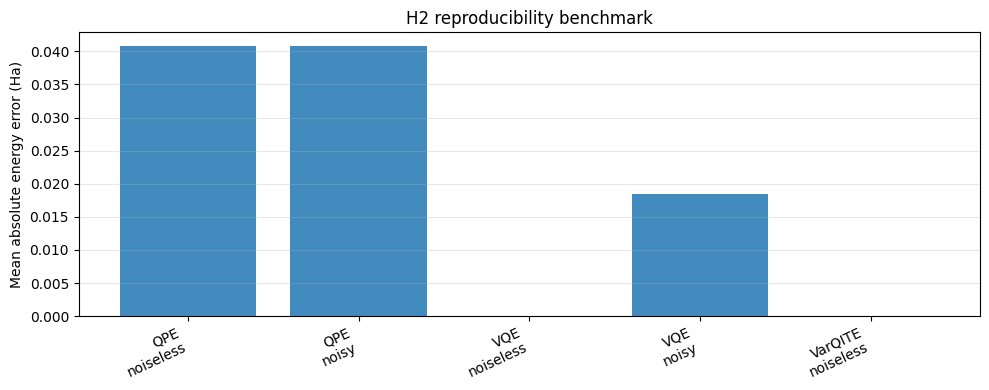

{'vqe': [{'file': 'H2_uccsd_adam_noiseless_s0_7f266d5b87f5.json',
   'keys': ['config', 'result'],
   'size_bytes': 11389},
  {'file': 'H2_uccsd_adam_noisy_x_dep01_s3_6906101c2147.json',
   'keys': ['config', 'result'],
   'size_bytes': 18789},
  {'file': 'H2_uccsd_adam_noiseless_s3_9a17a8a325aa.json',
   'keys': ['config', 'result'],
   'size_bytes': 11389}],
 'qite': [{'file': 'varqite_H2_uccsd_jordan_wigner_noiseless_steps50_dtau0p2_s0_6f0d646b15f9.json',
   'keys': ['config', 'result'],
   'size_bytes': 2954},
  {'file': 'varqite_H2_uccsd_jordan_wigner_noiseless_steps75_dtau0p2_s3_537a3fd0dad3.json',
   'keys': ['config', 'result'],
   'size_bytes': 3626},
  {'file': 'varqite_H2_uccsd_jordan_wigner_noiseless_steps75_dtau0p2_s2_5bb4cf9a3ea3.json',
   'keys': ['config', 'result'],
   'size_bytes': 3626}],
 'qpe': [{'file': 'H2_qpe_2ancilla_t1_b1a66d922fdc_s0.json',
   'keys': ['active_electrons',
    'active_orbitals',
    'basis',
    'best_bitstring',
    'charge',
    'counts',
  

In [10]:
labels = [f"{row['method']}\n{row['variant']}" for row in summary]
means = [row["abs_error_mean"] for row in summary]
stds = [row["energy_std"] for row in summary]

plt.figure(figsize=(10, 4))
plt.bar(labels, means, alpha=0.85)
plt.ylabel("Mean absolute energy error (Ha)")
plt.title("H2 reproducibility benchmark")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

artifact_notes = {
    "vqe": recent_artifacts("vqe"),
    "qite": recent_artifacts("qite"),
    "qpe": recent_artifacts("qpe"),
}
artifact_notes